# Principal Components Analysis Nutrition Exercise
En este ejercicio no vas a montar ningún modelo de Machine Learning supervisado, sino aprenderás a trabajar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlos, graficar y escoger número de componentes según varianza.

Importa las librerías necesarias

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Importa los datos
1. Importa los datos: *nndb.csv*
2. Observa las columnas que hay, así como su tipo.

In [7]:
nutri = pd.read_csv('./data/nndb_flat.csv')

In [8]:
nutri.info()

<class 'pandas.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8618 non-null   int64  
 1   FoodGroup         8618 non-null   str    
 2   ShortDescrip      8618 non-null   str    
 3   Descrip           8618 non-null   str    
 4   CommonName        1063 non-null   str    
 5   MfgName           1560 non-null   str    
 6   ScientificName    732 non-null    str    
 7   Energy_kcal       8618 non-null   float64
 8   Protein_g         8618 non-null   float64
 9   Fat_g             8618 non-null   float64
 10  Carb_g            8618 non-null   float64
 11  Sugar_g           8618 non-null   float64
 12  Fiber_g           8618 non-null   float64
 13  VitA_mcg          8618 non-null   float64
 14  VitB6_mg          8618 non-null   float64
 15  VitB12_mcg        8618 non-null   float64
 16  VitC_mg           8618 non-null   float64
 17  VitE_m

### Mira la correlación entre las variables numéricas
¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

<Axes: >

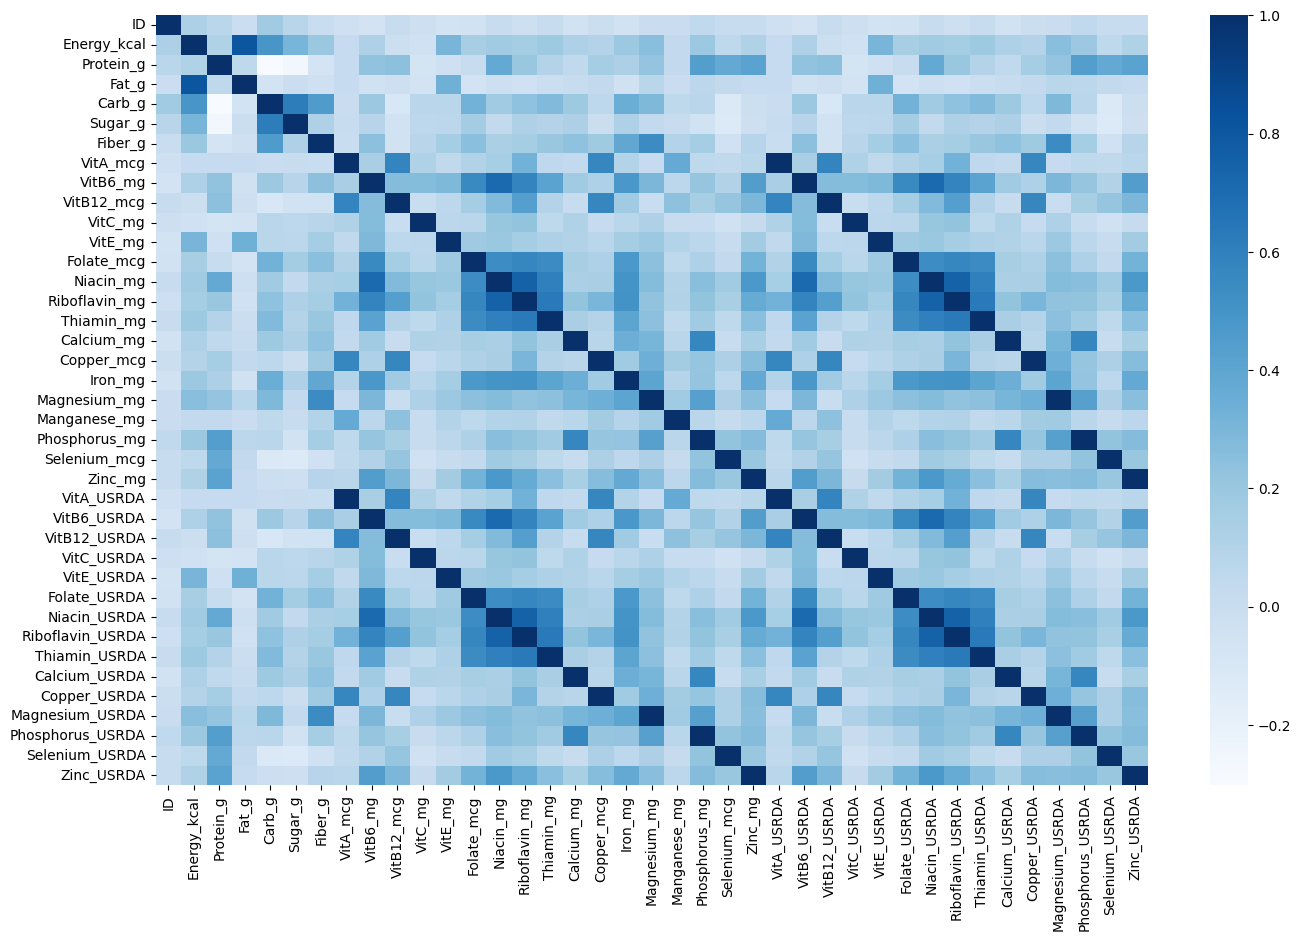

In [9]:
plt.figure(figsize=(16,10))
sns.heatmap(nutri.select_dtypes(include='number').corr(), annot=False, cmap='Blues')

Las variables USRDA estan linealmente muy correlacionadas

### Variables no numéricas
Elimina las variables de texto del dataset

In [10]:
nutri = nutri.select_dtypes(include='number').drop(columns=['ID'])

In [11]:
nutri.info()

<class 'pandas.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Energy_kcal       8618 non-null   float64
 1   Protein_g         8618 non-null   float64
 2   Fat_g             8618 non-null   float64
 3   Carb_g            8618 non-null   float64
 4   Sugar_g           8618 non-null   float64
 5   Fiber_g           8618 non-null   float64
 6   VitA_mcg          8618 non-null   float64
 7   VitB6_mg          8618 non-null   float64
 8   VitB12_mcg        8618 non-null   float64
 9   VitC_mg           8618 non-null   float64
 10  VitE_mg           8618 non-null   float64
 11  Folate_mcg        8618 non-null   float64
 12  Niacin_mg         8618 non-null   float64
 13  Riboflavin_mg     8618 non-null   float64
 14  Thiamin_mg        8618 non-null   float64
 15  Calcium_mg        8618 non-null   float64
 16  Copper_mcg        8618 non-null   float64
 17  Iron_m

In [12]:
nutri.skew().sort_values(ascending=False)

Manganese_mg        39.741772
Selenium_USRDA      38.207299
Selenium_mcg        38.207299
VitC_mg             30.907462
VitC_USRDA          30.907462
VitA_USRDA          24.090421
VitA_mcg            24.090421
Phosphorus_mg       18.553944
Phosphorus_USRDA    18.553944
Thiamin_USRDA       17.510062
Thiamin_mg          17.510062
Copper_USRDA        15.943149
Copper_mcg          15.943149
VitE_USRDA          13.849434
VitE_mg             13.849434
Calcium_mg          13.427978
Calcium_USRDA       13.427978
VitB12_USRDA        13.034297
VitB12_mcg          13.034297
Riboflavin_USRDA    11.312592
Riboflavin_mg       11.312592
Folate_mcg          10.327038
Folate_USRDA        10.327038
Zinc_mg              9.629128
Zinc_USRDA           9.629128
VitB6_USRDA          7.557554
VitB6_mg             7.557554
Iron_mg              6.839288
Niacin_USRDA         6.435334
Niacin_mg            6.435334
Fiber_g              5.793241
Magnesium_mg         5.565037
Magnesium_USRDA      5.565037
Fat_g     

### Distribuciones
Muchas de las variables tienen asimetría hacia la derecha. Deberíamos transformarlas para conseguir distribuciones normales y mejorar las correlaciones de cara al PCA y a futuros modelos lineales que vayamos a probar. Transforma todas las variables realizando una transformación Logarítmica.

<Axes: >

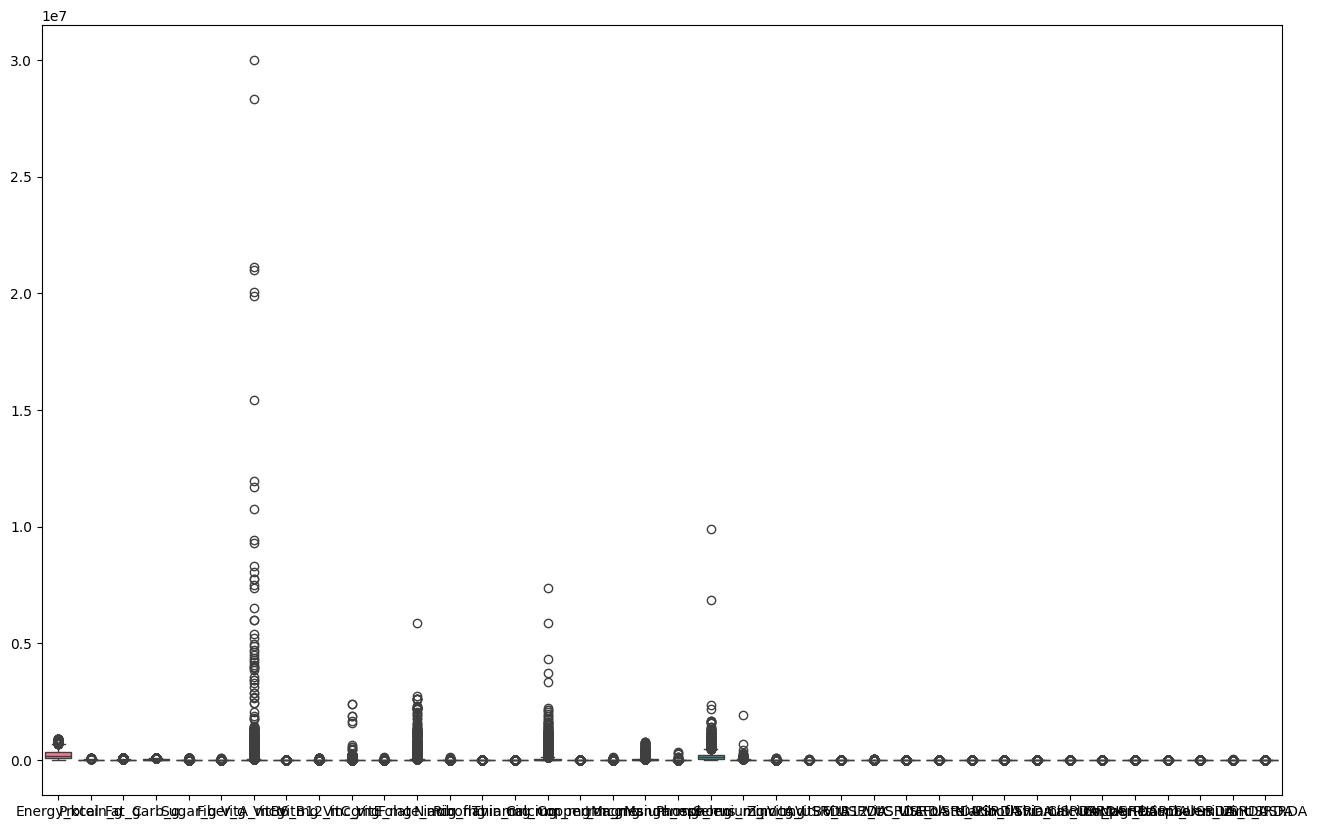

In [13]:
plt.figure(figsize=(16,10))
sns.boxplot(nutri * 1000)

Ekis de


<Axes: >

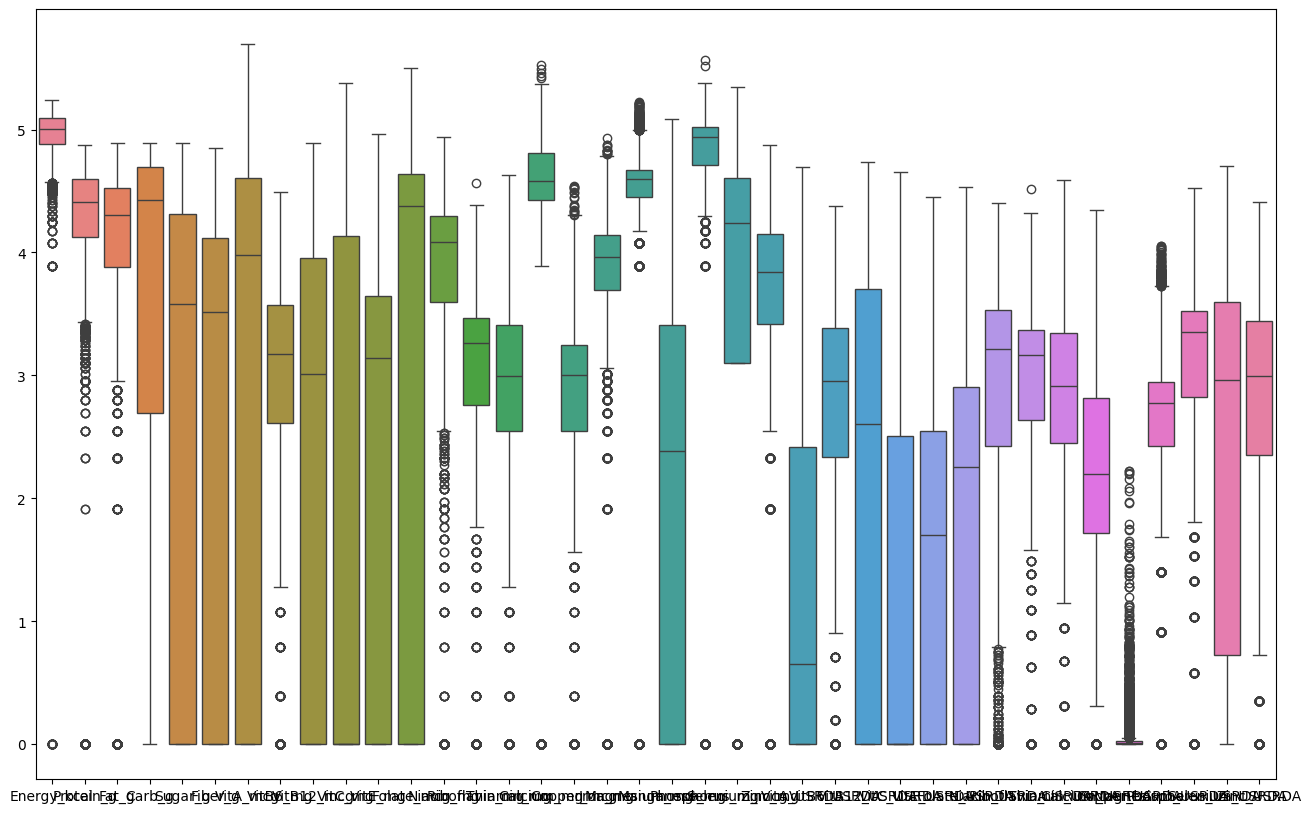

In [56]:
plt.figure(figsize=(16,10))
sns.boxplot(np.log1p(nutri**2))

In [15]:
nutri = np.log1p(nutri * 1000)

### Estandarizado
Estandariza cada variable.

No es necesario que dividas en train y test.

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
std = StandardScaler()
nutri_s = std.fit_transform(nutri)

In [18]:
pd.DataFrame(nutri_s, columns=nutri.columns)

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1.300195,-0.796449,1.431299,-0.708292,-0.089550,-1.033168,1.574928,-1.361703,0.431288,-0.851695,...,-0.246601,-1.450528,-0.499958,-1.234563,0.033333,-0.640155,-1.190006,-0.563241,-0.284978,-0.951867
1,1.300195,-0.796449,1.431299,-0.708292,-0.089550,-1.033168,1.574928,-1.361703,0.356274,-0.851695,...,-0.246601,-1.450528,-0.499958,-1.234563,0.033333,-0.558477,-1.190006,-0.586133,-0.284978,-1.215873
2,1.469781,-1.313960,1.518576,-1.659688,-1.032980,-1.033168,1.614863,-1.686768,-0.341127,-0.851695,...,-1.241926,-2.002860,-1.451706,-1.790447,-1.037406,-0.635008,-2.348524,-1.614813,-1.466181,-1.774176
3,0.700218,0.709665,0.987752,0.135854,0.393707,-1.033168,1.333953,0.388351,0.984681,-0.851695,...,0.856032,-0.025748,0.817174,-0.385094,2.098926,-0.438596,0.311553,0.961897,0.764440,0.762851
4,0.742328,0.748187,1.001511,0.176545,0.398243,-1.033168,1.409468,-0.047012,0.993756,-0.851695,...,0.586729,-1.036084,0.770598,-0.753440,2.264228,-0.518171,0.339213,1.046526,0.764440,0.750956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8613,0.576468,0.641658,0.929859,-1.659688,-1.032980,-1.033168,1.054409,0.810705,1.628036,-0.851695,...,0.455961,0.551952,0.433359,-0.574937,0.698789,-0.151796,0.938506,0.729176,1.411725,0.303584
8614,-0.279356,0.690510,-0.522021,0.329762,-1.032980,-1.033168,0.440831,0.205169,1.144093,-0.851695,...,0.586729,0.002221,-0.683908,-0.829132,-0.516852,-0.473242,0.621557,1.014988,0.925151,0.481631
8615,0.470123,-3.947320,-3.401177,0.932406,1.537599,-1.033168,-1.036760,-2.011833,-1.016173,-0.851695,...,-1.241926,-1.107476,-0.195161,0.402990,-0.355834,-0.538280,-0.224197,-1.141230,-0.418766,-0.591559
8616,-0.456924,0.576765,-0.303838,0.099535,-1.032980,-1.033168,0.967142,0.274487,0.733902,-0.851695,...,0.047579,0.130813,0.181757,-0.917284,-0.516852,1.064296,1.879084,0.767000,1.018203,0.254202


### Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [20]:
from sklearn.decomposition import PCA

In [24]:
nutri_s.shape[1]

38

In [42]:
pca = PCA(n_components=nutri_s.shape[1])
pca.fit(nutri_s)

In [57]:
df_pca = pd.DataFrame(pca.transform(nutri_s))

In [58]:
df_pca.head()

,0,1,2,3,4,5,6,7,8,9,...,28,29,30,31,32,33,34,35,36,37
0,-2.775564,-1.330841,3.005896,3.598765,0.665571,1.475158,1.451274,-0.635124,-0.747700,-1.270076,...,-0.138279,-0.112776,-0.082985,0.154719,0.084919,-0.041760,-0.021661,-0.007380,0.000344,-0.005180
1,-2.390877,-0.921874,2.936764,3.145550,1.117304,1.614977,1.734502,-0.642476,-0.489207,-0.786971,...,-0.120460,-0.080514,-0.088085,0.144603,0.096140,-0.052673,-0.024798,-0.013104,0.000030,-0.005267
2,-6.873614,-2.144863,3.297033,3.961201,0.804692,0.830427,2.406661,-1.140178,0.683720,-0.262770,...,0.031143,-0.444034,-0.152310,-0.574887,0.092484,-0.227555,-0.091175,-0.005539,0.017504,-0.012169
3,2.828597,-0.506927,1.760298,1.682079,-0.107395,2.483196,0.119901,-0.285320,-1.348194,-0.676429,...,0.008880,-0.008231,0.162743,0.028043,0.056194,0.031842,0.019372,0.001637,0.002216,0.005400
4,2.103069,-0.422036,2.055026,1.777832,0.177435,3.345929,0.071846,-0.557982,-1.270457,-1.033055,...,-0.090260,-0.035494,0.168355,0.033396,0.164448,0.068631,0.017152,0.005461,-0.001762,0.003981


### Aportación de cada PCA
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

------------------------------------------
Porcentaje de varianza explicada acumulada
------------------------------------------
[0.41237199 0.53901547 0.61182898 0.66780428 0.71854337 0.76128348
 0.78993418 0.81701081 0.84205184 0.86149036 0.87897311 0.89568681
 0.91070918 0.92401652 0.9344129  0.94363752 0.95163743 0.95890712
 0.96550918 0.97160951 0.97737141 0.98264766 0.98741761 0.99172648
 0.99413934 0.995917   0.99710761 0.99790375 0.99859139 0.99898698
 0.99935722 0.99964847 0.99982457 0.99997301 0.9999875  0.99999694
 0.99999918 1.        ]


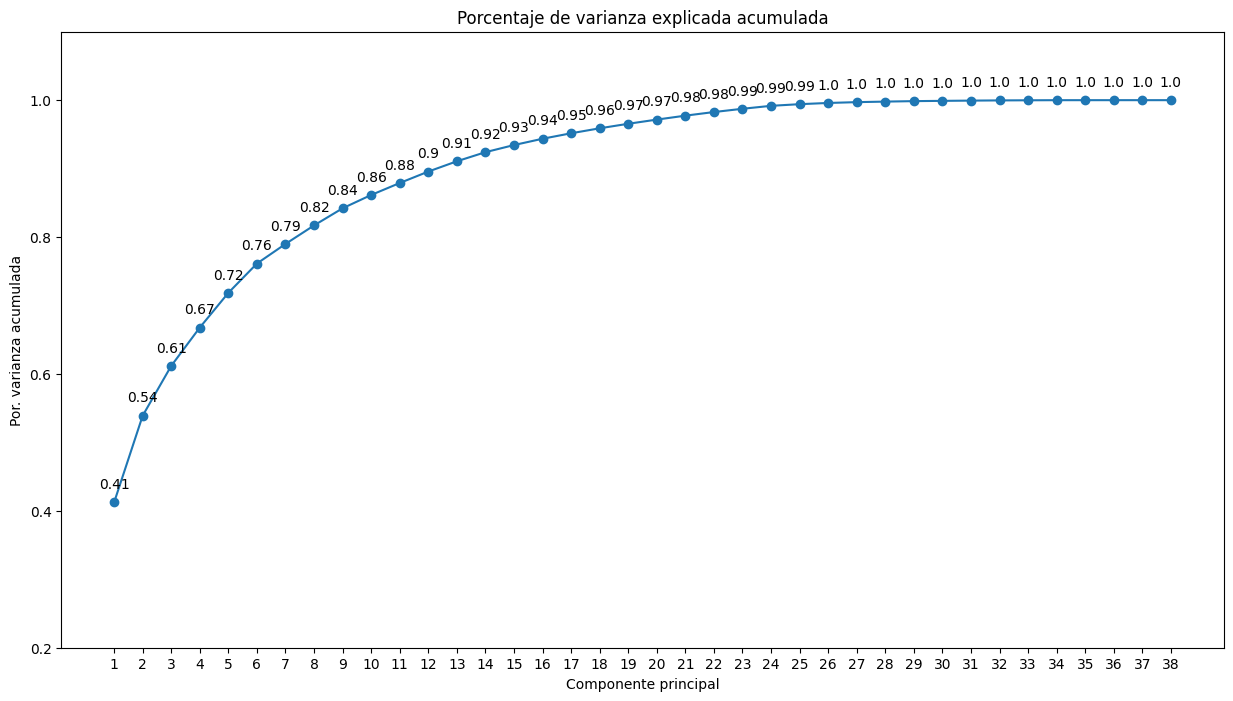

In [55]:
# Porcentaje de varianza explicada acumulada
# ==============================================================================
prop_varianza_acum = pca.explained_variance_ratio_.cumsum()
print('------------------------------------------')
print('Porcentaje de varianza explicada acumulada')
print('------------------------------------------')
print(prop_varianza_acum)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 8))

ax.plot(
    np.arange(len(nutri.columns)) + 1,
    prop_varianza_acum,
    marker = 'o'
)

for x, y in zip(np.arange(len(nutri.columns)) + 1, prop_varianza_acum):
    label = round(y, 2)
    ax.annotate(
        label,
        (x,y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )
    
ax.set_ylim(0.2, 1.1)
ax.set_xticks(np.arange(pca.n_components_) + 1)
ax.set_title('Porcentaje de varianza explicada acumulada')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza acumulada');

## Feat. Red
Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PC escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

In [61]:
df_pca.iloc[:, :5]

,0,1,2,3,4
0,-2.775564,-1.330841,3.005896,3.598765,0.665571
1,-2.390877,-0.921874,2.936764,3.145550,1.117304
2,-6.873614,-2.144863,3.297033,3.961201,0.804692
3,2.828597,-0.506927,1.760298,1.682079,-0.107395
4,2.103069,-0.422036,2.055026,1.777832,0.177435
...,...,...,...,...,...
8613,3.310616,-2.462875,2.793837,1.428880,0.500338
8614,0.895433,-1.903249,0.907582,-1.928328,-0.118085
8615,-4.178692,0.377670,-1.613594,-0.811880,-0.054044
8616,2.305902,-1.073560,2.344642,0.385028,1.639050


In [62]:
pca_2 = PCA(n_components=5)
proyecciones pca_2.fit(df_pca.iloc[:, :5])

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",5
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [63]:
df_pca = pd.DataFrame(pca_2.transform(df_pca.iloc[:, :5]))

In [65]:
df_pca.shape


(8618, 5)

In [67]:
nutri.shape

(8618, 38)

### ¿Qué grupo de comida tiene los valores más altos en cada categoría?
Determina para cada Principal Component, los 3 grupos de comida (*FoodGroup*) con los valores del PC más altos.